# 01. Аудит данных и разведочный анализ

Ноутбук показывает, **из чего сделан датасет** и почему выборке можно
доверять. Вся логика импортируется из `xg_context`: ноутбук ничего
не пересчитывает по-своему.

Предварительно должны быть выполнены:

```bash
python scripts/download_data.py --config configs/data.yaml --selection
python scripts/build_dataset.py --config configs/data.yaml
```

In [1]:
import json
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

In [2]:
from xg_context.config import PROCESSED_DATA_DIR, TABLES_DIR
from xg_context.visualization import (
    apply_style,
    plot_goal_rate_by_geometry,
    plot_sample_overview,
    plot_shot_map,
)

apply_style()

shots = pd.read_parquet(PROCESSED_DATA_DIR / 'context_eligible_shots.parquet')
audit = json.loads((TABLES_DIR / 'full_sample_audit.json').read_text(encoding='utf-8'))
shots.shape

(37487, 52)

## Состав выборки

Четыре мужские топ-лиги сезона 2015/2016. Лиги сопоставимы по объёму,
поэтому ни одна не доминирует в обучении.

In [3]:
by_league = pd.read_csv(TABLES_DIR / 'dataset_by_league.csv')
by_league[['competition_name', 'n_matches', 'n_shots', 'goal_rate']]

,competition_name,n_matches,n_shots,goal_rate
0,Serie A,380,9877,0.086868
1,Premier League,380,9817,0.093104
2,La Liga,380,9071,0.104178
3,Ligue 1,377,8723,0.097673


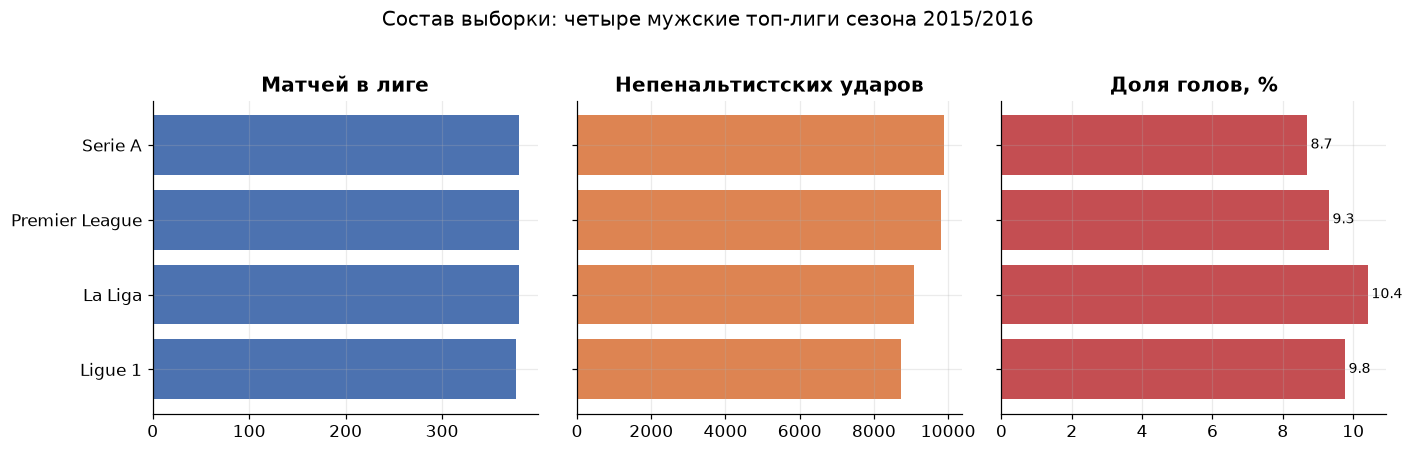

In [4]:
plot_sample_overview(by_league);

## Фильтры

Каждый шаг фильтрации показывает, сколько строк удалено и почему.
Единственный существенный фильтр — исключение пенальти.

In [5]:
pd.read_csv(TABLES_DIR / 'dataset_filters.csv')

,step,description,n_before,n_after,n_dropped,share_dropped
0,all_shots,Все события типа Shot,37888,37888,0,0.000000
1,drop_penalties,"Пенальти и удары серии пенальти (спецификация,...",37888,37488,400,0.010557
2,drop_unknown_outcome,Исход удара вне известной схемы StatsBomb,37488,37488,0,0.000000
3,drop_missing_location,Нет координат удара,37488,37488,0,0.000000
4,drop_missing_shot_id,Нет идентификатора события,37488,37488,0,0.000000
5,drop_duplicate_shot_id,Дубликаты shot_id,37488,37488,0,0.000000
6,context_eligible,Есть freeze_frame и хотя бы один соперник с ко...,37488,37487,1,0.000027


## Покрытие защитного контекста

Главный риск спецификации — неполный `freeze_frame` — на этих данных
не реализовался.

In [6]:
keys = [
    'share_with_freeze_frame',
    'share_with_opponent_coordinates',
    'share_with_goalkeeper',
    'share_with_statsbomb_xg',
    'goal_rate_all_eligible',
    'mean_opponents_visible',
]
pd.Series({k: audit[k] for k in keys}).round(5)

share_with_freeze_frame            1.00000
share_with_opponent_coordinates    0.99997
share_with_goalkeeper              0.99915
share_with_statsbomb_xg            1.00000
goal_rate_all_eligible             0.09520
mean_opponents_visible             7.50035
dtype: float64

**Ключевое ограничение.** В кадре видно в среднем около 7.5 соперника,
а не всех десятерых полевых игроков: `freeze_frame` ограничен полем
зрения камеры. Поэтому все счётчики обороны — это «сколько видно»,
и число видимых включено в модель признаком `n_opponents_visible`.

In [7]:
shots['n_opponents_visible'].describe().round(2)

count    37487.00
mean         7.50
std          1.84
min          1.00
25%          6.00
50%          8.00
75%          9.00
max         10.00
Name: n_opponents_visible, dtype: float64

## Где бьют и откуда забивают

Вопрос: как распределены удары и где доля голов максимальна?

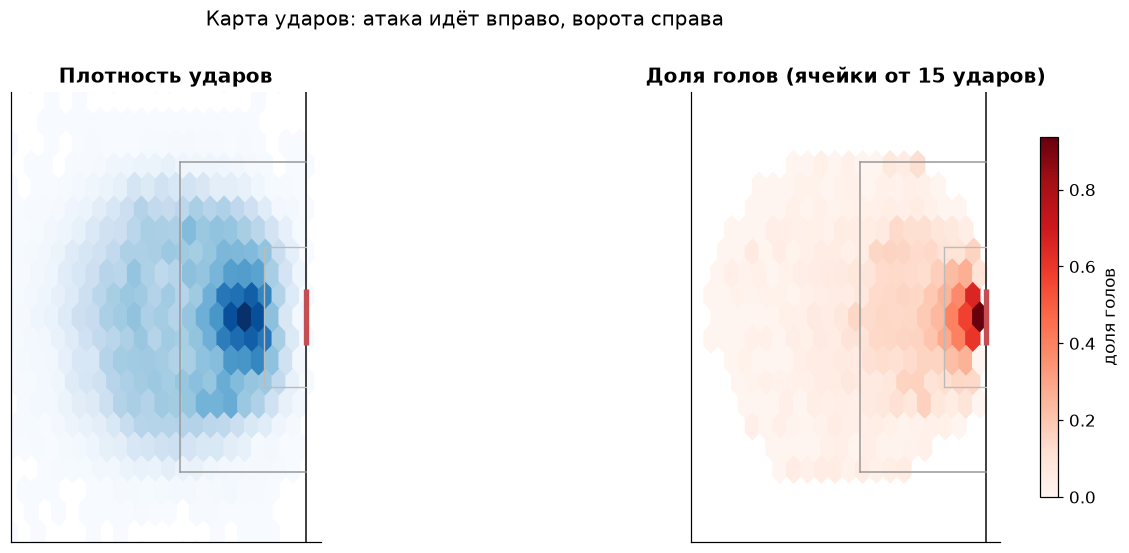

In [8]:
plot_shot_map(shots);

## Геометрия удара

Вопрос: достаточно ли линейной по расстоянию и углу модели?
Видно, что связь заметно нелинейна — это мотивирует нелинейные модели M3.

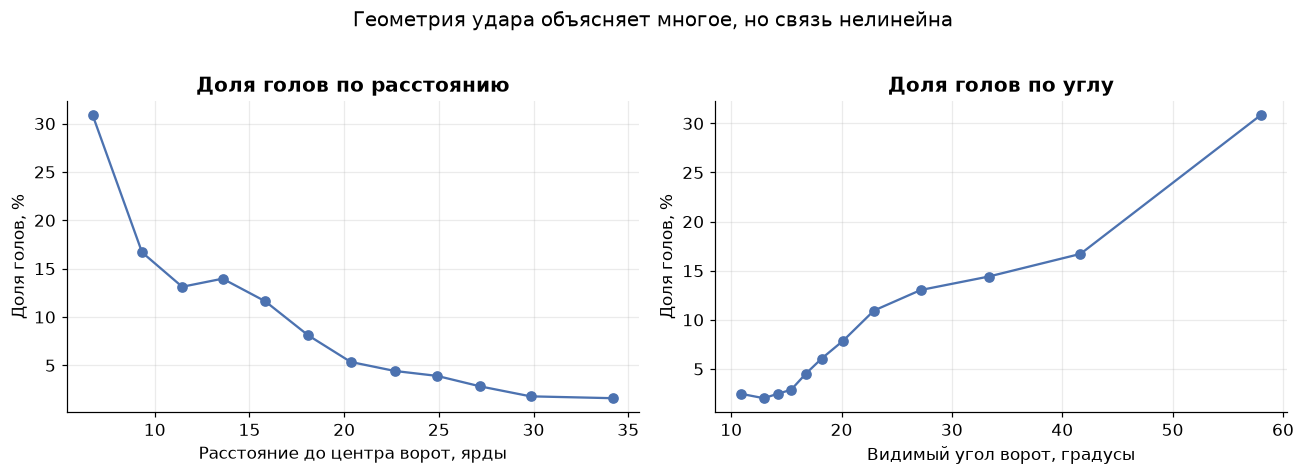

In [9]:
plot_goal_rate_by_geometry(shots);

## Защитный контекст и доля голов

Простая проверка до всякого моделирования: меняется ли доля голов
при разной плотности обороны, если зафиксировать расстояние?

In [10]:
band = shots[shots['shot_distance'].between(8, 16)]
band.groupby(band['opponents_in_shot_cone'].clip(upper=3)).agg(
    ударов=('is_goal', 'size'),
    доля_голов=('is_goal', 'mean'),
).round(4)

,ударов,доля_голов
opponents_in_shot_cone,,
0.0,6633,0.1811
1.0,3435,0.0972
2.0,959,0.0699
3.0,343,0.0525


Доля голов падает по мере роста числа соперников в конусе удара
**при одинаковом расстоянии**. Это ещё не доказательство прогностической
ценности, но обосновывает гипотезу H3.